In [2]:
df = pd.read_csv(r"D:\countypres_2000-2024.csv")

In [ ]:
import pandas as pd

df_elec = pd.read_csv(r"D:\countypres_2000-2024.csv")

df_elec = df_elec[(df_elec["year"] == 2020) & (df_elec["state"] == "MISSOURI")]
df_elec = df_elec.groupby(["county_name"], as_index=False)["candidatevotes"].sum()
df_elec = df_elec.rename(columns={"candidatevotes": "total_votes"})
df_elec["county_name"] = df_elec["county_name"].str.upper().str.strip()


df_pop = pd.read_excel(
    r"D:\co-est2025-pop-29.xlsx",
    sheet_name=0,
    header=None,
    skiprows=2
)


df_pop.columns = [
    "county_name",
    "est_base_2020",
    "population_2020",
    "population_2021",
    "population_2022",
    "population_2023",
    "population_2024",
    "population_2025"

df_pop = df_pop[["county_name", "population_2020"]]

df_pop["county_name"] = (
    df_pop["county_name"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(" County, Missouri", "", regex=False)
    .str.replace(", Missouri", "", regex=False)
    .str.upper()
    .str.strip()
)


df_pop = df_pop[df_pop["county_name"] != "MISSOURI"]


df_pop = df_pop.rename(columns={"population_2020": "population"})


df = pd.merge(df_elec, df_pop, on="county_name", how="inner")


df["turnout_rate"] = df["total_votes"] / df["population"]
df["registration_rate"] = 0.70
df["turnout_gap"] = df["registration_rate"] - df["turnout_rate"]

print(df.head())
print(df.shape)

  county_name  total_votes population turnout_rate  registration_rate  \
0       ADAIR      10336.0      25276     0.408925                0.7   
1      ANDREW       9752.0      18109     0.538517                0.7   
2    ATCHISON       2814.0       5307     0.530243                0.7   
3     AUDRAIN      10656.0      24778     0.430059                0.7   
4       BARRY      15598.0      34549     0.451475                0.7   

  turnout_gap  
0    0.291075  
1    0.161483  
2    0.169757  
3    0.269941  
4    0.248525  
(109, 6)


In [3]:
df_sorted = df.sort_values("turnout_gap", ascending=False)
print(df_sorted[["county_name", "turnout_rate", "turnout_gap"]].head(10))

    county_name turnout_rate turnout_gap
84      PULASKI     0.266901    0.433099
47      JACKSON     0.273699    0.426301
77     PEMISCOT     0.368029    0.331971
34      DUNKLIN     0.369259    0.330741
63     MCDONALD     0.388858    0.311142
66  MISSISSIPPI     0.391989    0.308011
91       SALINE     0.407945    0.292055
0         ADAIR     0.408925    0.291075
99     SULLIVAN     0.412865    0.287135
31       DEKALB      0.41732     0.28268


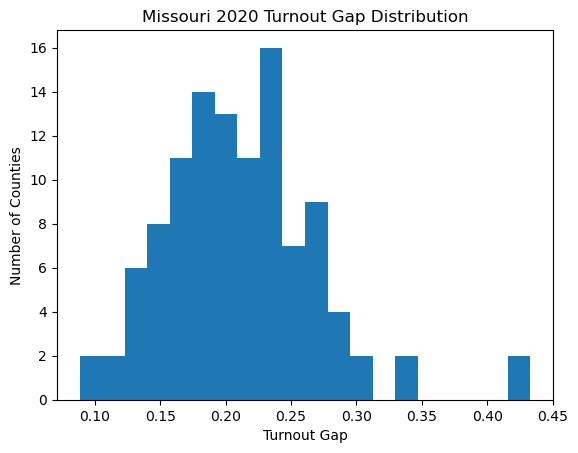

In [4]:
import matplotlib.pyplot as plt

plt.hist(df["turnout_gap"], bins=20)
plt.title("Missouri 2020 Turnout Gap Distribution")
plt.xlabel("Turnout Gap")
plt.ylabel("Number of Counties")
plt.show()